
TRAIN.TXT (full)
Total samples: 12915

Class counts:
  class 0: 4102
  class 1: 2247
  class 2: 5451
  class 3: 46
  class 4: 172
  class 5: 284
  class 6: 332
  class 7: 155
  class 8: 126

Class percentages:
  class 0: 31.76%
  class 1: 17.40%
  class 2: 42.21%
  class 3: 0.36%
  class 4: 1.33%
  class 5: 2.20%
  class 6: 2.57%
  class 7: 1.20%
  class 8: 0.98%

Imbalance ratio (max/min): 118.50x
Majority-class baseline accuracy: 0.4221 (always predict class 2)
Imbalance severity (rough): severe imbalance


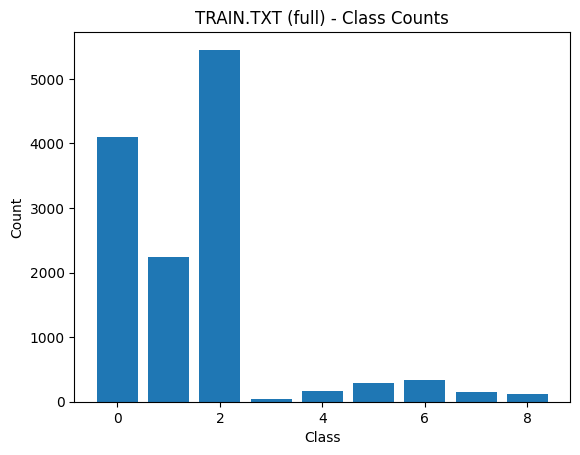

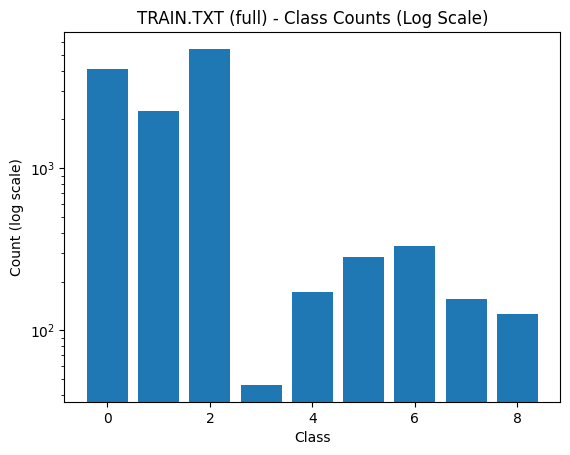

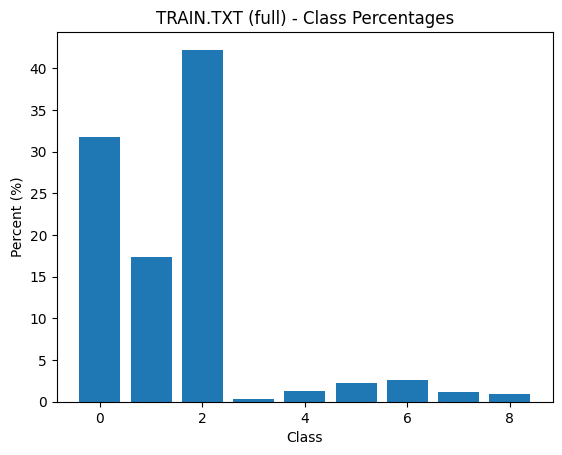


TRAIN SPLIT (val_split=0.15, seed=42)
Total samples: 10978

Class counts:
  class 0: 3499
  class 1: 1904
  class 2: 4635
  class 3: 40
  class 4: 146
  class 5: 235
  class 6: 281
  class 7: 132
  class 8: 106

Class percentages:
  class 0: 31.87%
  class 1: 17.34%
  class 2: 42.22%
  class 3: 0.36%
  class 4: 1.33%
  class 5: 2.14%
  class 6: 2.56%
  class 7: 1.20%
  class 8: 0.97%

Imbalance ratio (max/min): 115.88x
Majority-class baseline accuracy: 0.4222 (always predict class 2)
Imbalance severity (rough): severe imbalance


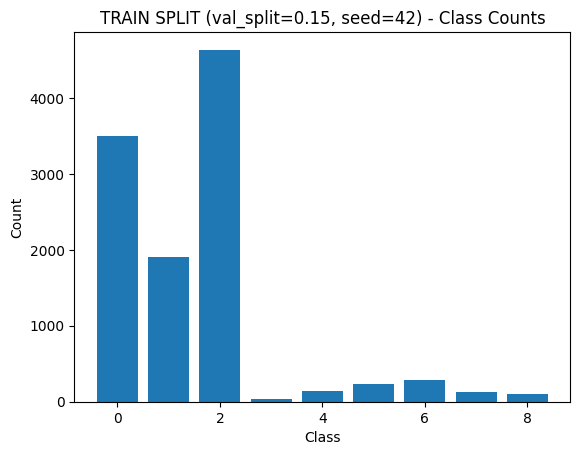

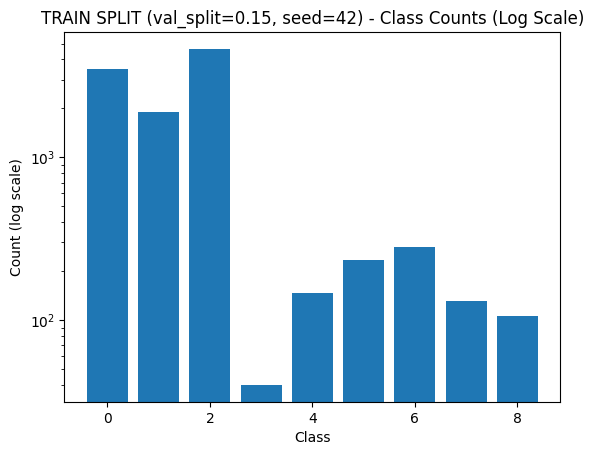

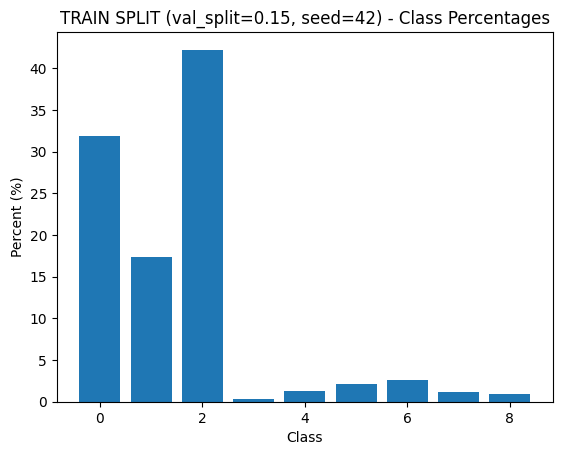


VAL SPLIT (val_split=0.15, seed=42)
Total samples: 1937

Class counts:
  class 0: 603
  class 1: 343
  class 2: 816
  class 3: 6
  class 4: 26
  class 5: 49
  class 6: 51
  class 7: 23
  class 8: 20

Class percentages:
  class 0: 31.13%
  class 1: 17.71%
  class 2: 42.13%
  class 3: 0.31%
  class 4: 1.34%
  class 5: 2.53%
  class 6: 2.63%
  class 7: 1.19%
  class 8: 1.03%

Imbalance ratio (max/min): 136.00x
Majority-class baseline accuracy: 0.4213 (always predict class 2)
Imbalance severity (rough): severe imbalance


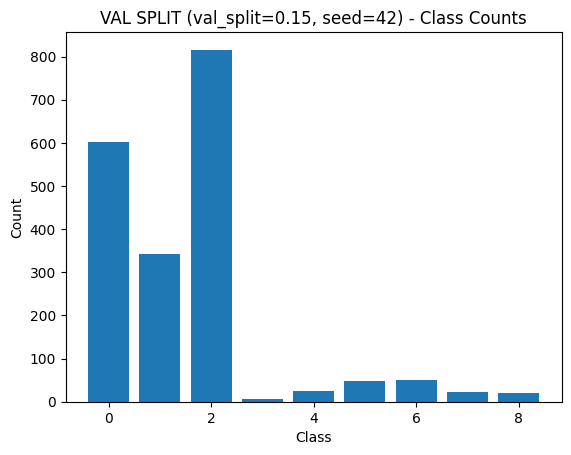

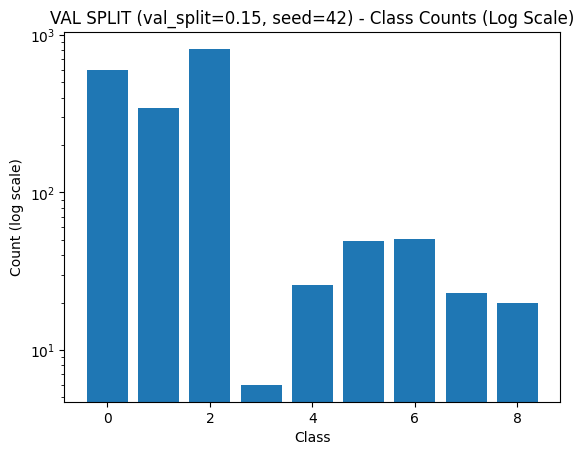

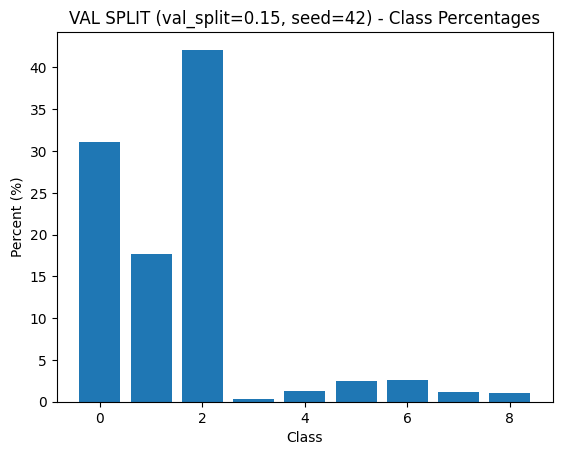


TEST.TXT (full)
Total samples: 3296

Class counts:
  class 0: 1048
  class 1: 576
  class 2: 1388
  class 3: 12
  class 4: 44
  class 5: 72
  class 6: 84
  class 7: 40
  class 8: 32

Class percentages:
  class 0: 31.80%
  class 1: 17.48%
  class 2: 42.11%
  class 3: 0.36%
  class 4: 1.33%
  class 5: 2.18%
  class 6: 2.55%
  class 7: 1.21%
  class 8: 0.97%

Imbalance ratio (max/min): 115.67x
Majority-class baseline accuracy: 0.4211 (always predict class 2)
Imbalance severity (rough): severe imbalance


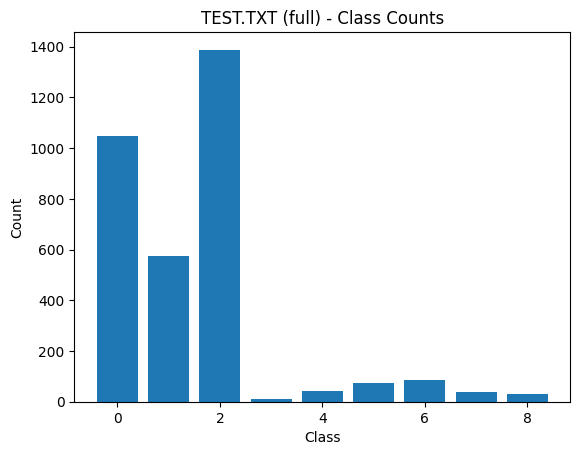

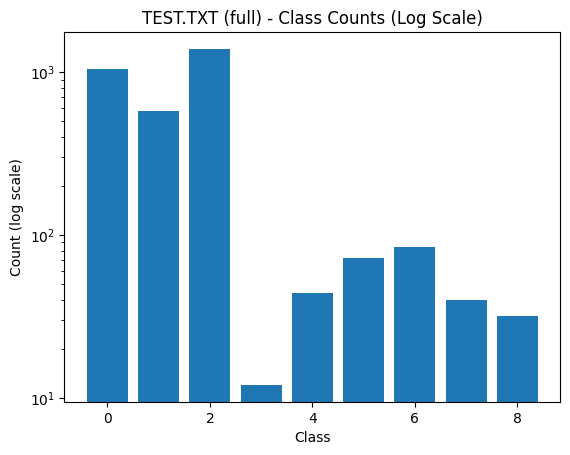

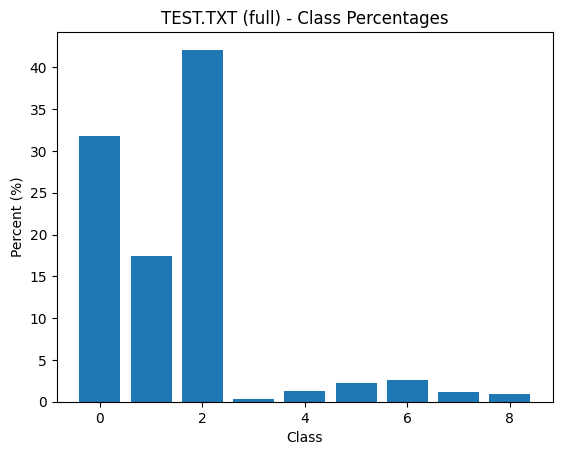

In [2]:
# If you're in a notebook, run this cell once:
%matplotlib inline

import os
from collections import Counter

import torch
import matplotlib.pyplot as plt


# -----------------
# Config (edit if needed)
# -----------------
ROOT_DIR = "/anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main"
TRAIN_TXT = os.path.join(ROOT_DIR, "train.txt")
TEST_TXT  = os.path.join(ROOT_DIR, "test.txt")

VAL_SPLIT = 0.15
SEED = 42


def load_txt(txt_path):
    paths, labels = [], []
    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            paths.append(parts[0])
            labels.append(int(parts[1]))
    return paths, labels


def print_distribution(name, labels):
    counts = Counter(labels)
    total = len(labels)

    print("\n" + "=" * 70)
    print(f"{name}")
    print("=" * 70)
    print(f"Total samples: {total}")

    classes = sorted(counts.keys())
    print("\nClass counts:")
    for c in classes:
        print(f"  class {c}: {counts[c]}")

    print("\nClass percentages:")
    for c in classes:
        print(f"  class {c}: {counts[c] / total * 100:.2f}%")

    max_count = max(counts.values())
    min_count = min(counts.values())
    ratio = max_count / min_count if min_count > 0 else float("inf")
    print(f"\nImbalance ratio (max/min): {ratio:.2f}x")

    majority_class, majority_count = counts.most_common(1)[0]
    majority_baseline = majority_count / total
    print(f"Majority-class baseline accuracy: {majority_baseline:.4f} "
          f"(always predict class {majority_class})")

    if ratio <= 2:
        severity = "mild or balanced"
    elif ratio <= 5:
        severity = "moderate imbalance"
    elif ratio <= 10:
        severity = "strong imbalance"
    else:
        severity = "severe imbalance"
    print(f"Imbalance severity (rough): {severity}")


def plot_distribution_inline(name, labels):
    """
    Shows 3 plots inline in the notebook:
      1) raw counts
      2) log-scale counts (recommended for extreme imbalance)
      3) percentages
    """
    counts = Counter(labels)
    classes = sorted(counts.keys())
    values = [counts[c] for c in classes]
    total = len(labels)
    perc = [v / total * 100.0 for v in values]

    # 1) Raw counts
    plt.figure()
    plt.bar(classes, values)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(f"{name} - Class Counts")
    plt.show()

    # 2) Log-scale counts
    plt.figure()
    plt.bar(classes, values)
    plt.yscale("log")
    plt.xlabel("Class")
    plt.ylabel("Count (log scale)")
    plt.title(f"{name} - Class Counts (Log Scale)")
    plt.show()

    # 3) Percentages
    plt.figure()
    plt.bar(classes, perc)
    plt.xlabel("Class")
    plt.ylabel("Percent (%)")
    plt.title(f"{name} - Class Percentages")
    plt.show()


def make_train_val_split(labels, val_split=0.15, seed=42):
    """Deterministic split indices similar to random_split."""
    n = len(labels)
    val_size = int(n * val_split)
    train_size = n - val_size

    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g).tolist()

    train_idx = perm[:train_size]
    val_idx = perm[train_size:]
    return train_idx, val_idx


def run_all():
    if not os.path.exists(TRAIN_TXT):
        raise FileNotFoundError(f"TRAIN_TXT not found: {TRAIN_TXT}")

    # Train.txt distribution (full, before split)
    _, train_labels = load_txt(TRAIN_TXT)
    print_distribution("TRAIN.TXT (full)", train_labels)
    plot_distribution_inline("TRAIN.TXT (full)", train_labels)

    # Train/Val split distributions
    train_idx, val_idx = make_train_val_split(train_labels, VAL_SPLIT, SEED)
    train_split_labels = [train_labels[i] for i in train_idx]
    val_split_labels = [train_labels[i] for i in val_idx]

    train_name = f"TRAIN SPLIT (val_split={VAL_SPLIT}, seed={SEED})"
    val_name = f"VAL SPLIT (val_split={VAL_SPLIT}, seed={SEED})"

    print_distribution(train_name, train_split_labels)
    plot_distribution_inline(train_name, train_split_labels)

    print_distribution(val_name, val_split_labels)
    plot_distribution_inline(val_name, val_split_labels)

    # Test.txt distribution (if exists)
    if os.path.exists(TEST_TXT):
        _, test_labels = load_txt(TEST_TXT)
        print_distribution("TEST.TXT (full)", test_labels)
        plot_distribution_inline("TEST.TXT (full)", test_labels)
    else:
        print("\nNOTE: test.txt not found, skipping test distribution.")


# Run everything
run_all()